# Predict-then-optimise with quarterly PD and Basel IRB

This notebook adapts the old PTO scaffold to the new quarterly-PD decision problem.

Key convention:

- the raw FRED charge-off series used here is annualised and stored in percent units;
- it is converted to a decimal annual rate, then to a quarterly charge-off rate before target construction;
- the forecasting target is next-quarter realised PD, `PD_Q_{t+1} = c_q_{t+1} / LGD`;
- the model predicts quarterly PD, and quarterly PD enters the decision through the expected quarterly loss/return component;
- quarterly PD is annualised only for Basel IRB capital requirements and the Basel asset-correlation formula.

No stress-probability target, Gaussian-mixture layer, or old decision objective is used.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
except ImportError as exc:
    raise ImportError(
        "This notebook needs PyTorch for the linear and MLP PTO models. "
        "Install the project requirements or select the project kernel."
    ) from exc

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "data" / "processed" / "fred_loan_return_aligned.csv").exists():
    ROOT = ROOT.parent

FIGURES_DIR = ROOT / "figures" / "pto_pd_irb"
RESULTS_DIR = ROOT / "models" / "notebooks" / "results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Project root: {ROOT}")
print(f"Figures: {FIGURES_DIR.relative_to(ROOT)}")
print(f"Results: {RESULTS_DIR.relative_to(ROOT)}")

Project root: /Users/hannahokeeffe/Documents/Imperial/DFL_New
Figures: figures/pto_pd_irb
Results: models/notebooks/results


## Configuration

`CHARGE_OFF_CONVERSION = "compound"` treats the annualised charge-off rate as an annual rate and converts it to the equivalent quarterly rate using compounding. If the source is interpreted as a simple annual-rate convention, set it to `"simple"`, which applies the older divide-by-four convention explicitly.

In [2]:
# Data conventions
CHARGE_OFF_IS_PERCENT = True
CHARGE_OFF_CONVERSION = "compound"  # alternatives: "simple"
HORIZON = 1
DATE_COL = "DATE"
TARGET_COL = "charge_off_rate"

# Decision and Basel constants
LGD = 0.45
M = 2.5
K1 = 1.0
LEVERAGE = 10.0
Y_BAR = 0.0168
LAMBDA = 10.0

PD_Q_CLIP_LOW = 1e-6
PD_Q_CLIP_HIGH = 0.99
PD_A_CLIP_LOW = 1e-6
PD_A_CLIP_HIGH = 0.99
ALPHA_GRID = np.linspace(0.0, 1.0, 101)

@dataclass
class ModelConfig:
    hidden_dim: int = 16
    lr: float = 1e-3
    weight_decay: float = 1e-4
    batch_size: int = 16
    epochs: int = 500
    patience: int = 75
    val_frac: float = 0.2
    seed: int = 42

MODEL_CFG = ModelConfig()
INITIAL_TRAIN_FRAC = 0.75

## Quarterly PD, Basel IRB, and allocation objective

In [3]:
def annual_chargeoff_to_quarterly(c_annual, conversion=CHARGE_OFF_CONVERSION):
    c_annual = np.asarray(c_annual, dtype=float)
    if conversion == "compound":
        return 1.0 - np.power(1.0 - c_annual, 1.0 / 4.0)
    if conversion == "simple":
        return c_annual / 4.0
    raise ValueError("CHARGE_OFF_CONVERSION must be 'compound' or 'simple'.")


def clip_pd_q(pd_q):
    return np.clip(np.asarray(pd_q, dtype=float), PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH)


def clip_pd_a(pd_a):
    return np.clip(np.asarray(pd_a, dtype=float), PD_A_CLIP_LOW, PD_A_CLIP_HIGH)


def quarterly_pd_to_annual(pd_q):
    pd_q = clip_pd_q(pd_q)
    return clip_pd_a(1.0 - np.power(1.0 - pd_q, 4.0))


def k_irb_from_annual_pd(pd_a, lgd=LGD, m=M):
    # Basel IRB capital requirement per unit exposure. Input must be annual PD.
    pd_a = clip_pd_a(pd_a)
    exp_term = (1.0 - np.exp(-50.0 * pd_a)) / (1.0 - np.exp(-50.0))
    r = 0.12 * exp_term + 0.24 * (1.0 - exp_term)
    b = np.square(0.11852 - 0.05478 * np.log(pd_a))
    maturity_adj = (1.0 + (m - 2.5) * b) / (1.0 - 1.5 * b)
    z = norm.ppf(pd_a) / np.sqrt(1.0 - r) + np.sqrt(r / (1.0 - r)) * norm.ppf(0.999)
    k_irb = lgd * (norm.cdf(z) - pd_a) * maturity_adj
    return np.maximum(k_irb, 0.0)


def allocation_utility(alpha, c_q, pd_a, leverage=LEVERAGE, y_bar=Y_BAR, lambda_penalty=LAMBDA, k1=K1, lgd=LGD, m=M):
    # U(alpha; c_q, pd_a), with pd_a used only for Basel IRB capital.
    alpha = np.asarray(alpha, dtype=float)
    c_q = float(c_q)
    pd_a = float(clip_pd_a(pd_a))
    exposure = leverage * alpha * k1
    terminal_capital = k1 + exposure * (y_bar - c_q)
    committed_capital = alpha * k1
    available_buffer = terminal_capital - committed_capital
    required_capital = k_irb_from_annual_pd(pd_a, lgd=lgd, m=m) * exposure
    shortfall = np.maximum(required_capital - available_buffer, 0.0)
    return terminal_capital - lambda_penalty * shortfall


def decision_components(alpha, c_q, pd_a):
    exposure = LEVERAGE * alpha * K1
    terminal_capital = K1 + exposure * (Y_BAR - c_q)
    committed_capital = alpha * K1
    available_buffer = terminal_capital - committed_capital
    k_irb = float(k_irb_from_annual_pd(pd_a))
    required_capital = k_irb * exposure
    shortfall = max(required_capital - available_buffer, 0.0)
    utility = terminal_capital - LAMBDA * shortfall
    return dict(exposure=exposure, terminal_capital=terminal_capital, committed_capital=committed_capital,
                available_buffer=available_buffer, required_capital=required_capital, shortfall=shortfall,
                utility=utility, k_irb=k_irb)


def optimise_alpha_grid(c_q, pd_a, alpha_grid=ALPHA_GRID):
    utilities = allocation_utility(alpha_grid, c_q=c_q, pd_a=pd_a)
    best_idx = int(np.argmax(utilities))
    return float(alpha_grid[best_idx]), float(utilities[best_idx])

## Load and align data

The forecasting row is `x_t -> PD_Q_{t+1}`. Result columns are named for the realised next-period outcome, because that is the period used for decision evaluation.

The feature set includes the observed lagged quarterly charge-off rate `c_q_lag1 = c_{q,t-1}`. It deliberately does not include any lagged PD feature: realised PD is constructed from charge-offs for the target/evaluation convention, not treated as an observed model signal.

In [4]:
def load_quarterly_pd_panel(macro_csv, chargeoff_csv, date_col=DATE_COL, target_col=TARGET_COL, feature_cols=None, horizon=HORIZON):
    macro = pd.read_csv(macro_csv)
    charge = pd.read_csv(chargeoff_csv)
    macro[date_col] = pd.to_datetime(macro[date_col]).dt.to_period("Q").dt.start_time
    charge[date_col] = pd.to_datetime(charge[date_col]).dt.to_period("Q").dt.start_time

    if target_col not in charge.columns:
        raise ValueError(f"{target_col!r} not found in charge-off columns: {list(charge.columns)}")

    charge["c_annual_raw"] = pd.to_numeric(charge[target_col], errors="coerce")
    charge["c_annual_decimal"] = charge["c_annual_raw"] / 100.0 if CHARGE_OFF_IS_PERCENT else charge["c_annual_raw"]
    charge["c_q"] = annual_chargeoff_to_quarterly(charge["c_annual_decimal"].to_numpy())
    charge["pd_q"] = clip_pd_q(charge["c_q"].to_numpy() / LGD)
    charge["pd_a"] = quarterly_pd_to_annual(charge["pd_q"].to_numpy())

    keep_charge = [date_col, "c_annual_raw", "c_annual_decimal", "c_q", "pd_q", "pd_a"]
    df = pd.merge(macro, charge[keep_charge], on=date_col, how="inner").sort_values(date_col).reset_index(drop=True)

    # Observed autoregressive signal: previous quarter charge-off rate.
    # Do not add a PD lag; PD is constructed for targeting/evaluation, not an observed feature.
    df["c_q_lag1"] = df["c_q"].shift(1)

    df["target_date"] = df[date_col].shift(-horizon)
    df["c_annual_raw_next"] = df["c_annual_raw"].shift(-horizon)
    df["c_q_realised"] = df["c_q"].shift(-horizon)
    df["pd_q_realised"] = df["pd_q"].shift(-horizon)
    df["pd_a_realised"] = df["pd_a"].shift(-horizon)
    df["target_pd_q_next"] = df["pd_q_realised"]

    if feature_cols is None:
        exclude = {date_col, "c_annual_raw", "c_annual_decimal", "c_q", "pd_q", "pd_a", "target_date",
                   "c_annual_raw_next", "c_q_realised", "pd_q_realised", "pd_a_realised", "target_pd_q_next"}
        feature_cols = [c for c in df.columns if c not in exclude]
    else:
        feature_cols = list(feature_cols)

    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    required = feature_cols + ["target_date", "c_annual_raw_next", "c_q_realised", "pd_q_realised", "pd_a_realised", "target_pd_q_next"]
    df = df.dropna(subset=required).reset_index(drop=True)
    if len(df) < 30:
        raise ValueError(f"Only {len(df)} usable observations after alignment; check dates and missing values.")
    df.attrs["feature_cols"] = feature_cols
    return df

macro_csv = ROOT / "data" / "processed" / "macro_panel_quarterly.csv"
chargeoff_csv = ROOT / "data" / "processed" / "fred_loan_return_aligned.csv"
df = load_quarterly_pd_panel(macro_csv, chargeoff_csv)
feature_cols = df.attrs["feature_cols"]

print(f"Observations after alignment and one-step target: {len(df)}")
print(f"Feature date range: {df[DATE_COL].min().date()} to {df[DATE_COL].max().date()}")
print(f"Target date range: {df['target_date'].min().date()} to {df['target_date'].max().date()}")
print(f"Features ({len(feature_cols)}): {feature_cols}")
assert "c_q_lag1" in feature_cols
assert not any(col.startswith("pd_q_lag") or col.startswith("pd_a_lag") for col in feature_cols)
print("Lag feature included: c_q_lag1; PD lags excluded.")
display(df.head())

Observations after alignment and one-step target: 142
Feature date range: 1990-07-01 to 2025-10-01
Target date range: 1990-10-01 to 2026-01-01
Features (13): ['real_gdp_growth', 'unemployment_rate', 'industrial_production', 'real_disposable_personal_income', 'cpi', 'house_price_index', 'federal_funds_rate', 'treasury_10y_2y_spread', 'vix', 'corporate_bond_spread', 'senior_loan_officer_survey', 'excess_bond_premium', 'c_q_lag1']
Lag feature included: c_q_lag1; PD lags excluded.


,DATE,real_gdp_growth,unemployment_rate,industrial_production,real_disposable_personal_income,cpi,house_price_index,federal_funds_rate,treasury_10y_2y_spread,vix,...,c_q,pd_q,pd_a,c_q_lag1,target_date,c_annual_raw_next,c_q_realised,pd_q_realised,pd_a_realised,target_pd_q_next
0,1990-07-01,0.3,5.700000,0.386851,0.014248,1.712502,0.607283,8.160000,0.602540,25.195556,...,0.003215,0.007146,0.028277,0.003594,1990-10-01,1.30,0.003266,0.007258,0.028716,0.007258
1,1990-10-01,-3.6,6.133333,-1.560018,-0.804251,1.683668,-0.390403,7.743333,0.800161,26.113281,...,0.003266,0.007258,0.028716,0.003215,1991-01-01,1.48,0.003721,0.008268,0.032665,0.008268
2,1991-01-01,-1.9,6.600000,-1.932577,0.306683,0.744790,0.833014,6.426667,0.987167,22.515833,...,0.003721,0.008268,0.032665,0.003266,1991-04-01,1.86,0.004683,0.010406,0.040980,0.010406
3,1991-04-01,3.2,6.833333,0.526353,0.748178,0.591864,0.660265,5.863333,1.231406,17.147031,...,0.004683,0.010406,0.040980,0.003721,1991-07-01,1.97,0.004962,0.011026,0.043381,0.011026
4,1991-07-01,2.0,6.866667,1.390822,0.383417,0.759342,0.195457,5.643333,1.428906,16.634219,...,0.004962,0.011026,0.043381,0.004683,1991-10-01,1.83,0.004607,0.010237,0.040324,0.010237


## Models and training loop

Both models output a sigmoid-transformed quarterly PD. Training minimises MSE between predicted quarterly PD and realised next-quarter `PD_Q`.

In [5]:
class PDForecaster(nn.Module):
    def __init__(self, input_dim, model_type, hidden_dim=16):
        super().__init__()
        if model_type == "linear":
            self.net = nn.Linear(input_dim, 1)
        elif model_type == "mlp":
            self.net = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(),
                                     nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1))
        else:
            raise ValueError("model_type must be 'linear' or 'mlp'.")

    def forward(self, x):
        return torch.sigmoid(self.net(x)).squeeze(-1)


def init_output_bias_for_target(model, y_train):
    """Set the sigmoid output bias to logit(mean(y_train)).

    Quarterly PD targets are small, so sigmoid(0)=0.5 is far too high as an
    initial prediction. This starts each expanding-window fit near the current
    training-window mean PD instead.
    """
    y_mean = float(np.clip(np.mean(y_train), PD_Q_CLIP_LOW, 1.0 - PD_Q_CLIP_LOW))
    logit_mean = np.log(y_mean / (1.0 - y_mean))
    with torch.no_grad():
        if isinstance(model.net, nn.Linear):
            model.net.bias.fill_(logit_mean)
        else:
            model.net[-1].bias.fill_(logit_mean)


def train_pd_model(x_train, y_train_pd_q, model_type, model_cfg, return_history=False):
    torch.manual_seed(model_cfg.seed)
    np.random.seed(model_cfg.seed)
    n = x_train.shape[0]
    val_size = max(1, int(np.floor(model_cfg.val_frac * n)))
    train_size = n - val_size
    if train_size < 8:
        raise ValueError("Training set too small after validation split.")

    x_tr, x_val = x_train[:train_size], x_train[train_size:]
    y_tr, y_val = y_train_pd_q[:train_size], y_train_pd_q[train_size:]
    train_ds = TensorDataset(torch.tensor(x_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.float32))
    train_loader = DataLoader(train_ds, batch_size=model_cfg.batch_size, shuffle=False)

    model = PDForecaster(input_dim=x_train.shape[1], model_type=model_type, hidden_dim=model_cfg.hidden_dim)
    init_output_bias_for_target(model, y_train_pd_q)
    optimiser = torch.optim.AdamW(model.parameters(), lr=model_cfg.lr, weight_decay=model_cfg.weight_decay)
    loss_fn = nn.MSELoss()
    x_val_t = torch.tensor(x_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32)
    best_state, best_val, stale_epochs, history = None, float("inf"), 0, []

    for epoch in range(model_cfg.epochs):
        model.train(); batch_losses = []
        for xb, yb in train_loader:
            optimiser.zero_grad()
            pd_q_hat = model(xb)
            loss = loss_fn(pd_q_hat, yb)
            loss.backward(); optimiser.step()
            batch_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            pd_q_val = model(x_val_t)
            val_loss = loss_fn(pd_q_val, y_val_t).item()
        pd_q_val_np = clip_pd_q(pd_q_val.detach().cpu().numpy())
        history.append({"epoch": epoch + 1, "model": model_type, "train_loss": float(np.mean(batch_losses)),
                        "val_loss": float(val_loss),
                        "val_rmse_pd_q": float(np.sqrt(mean_squared_error(y_val, pd_q_val_np))),
                        "val_mae_pd_q": float(mean_absolute_error(y_val, pd_q_val_np)),
                        "val_mean_pd_q_hat": float(np.mean(pd_q_val_np))})

        if val_loss < best_val - 1e-12:
            best_val = val_loss
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            stale_epochs = 0
        else:
            stale_epochs += 1
        if stale_epochs >= model_cfg.patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return (model, pd.DataFrame(history)) if return_history else model


def predict_pd_q(model, x):
    model.eval()
    with torch.no_grad():
        pred = model(torch.tensor(x, dtype=torch.float32)).detach().cpu().numpy()
    return clip_pd_q(pred)

## Expanding-window evaluation

At each test date, the scaler and model are refit using only observations available before that feature date. PTO allocation is chosen from predicted quarterly PD; realised utility and regret are evaluated with realised next-quarter charge-offs and realised annualised PD.

In [6]:
def build_result_row(base_row, pd_q_hat, model_name):
    pd_q_hat = float(clip_pd_q(pd_q_hat))
    c_q_hat = float(LGD * pd_q_hat)
    pd_a_hat = float(quarterly_pd_to_annual(pd_q_hat))
    c_q_realised = float(base_row["c_q_realised"])
    pd_q_realised = float(base_row["pd_q_realised"])
    pd_a_realised = float(base_row["pd_a_realised"])

    alpha_hat, _ = optimise_alpha_grid(c_q=c_q_hat, pd_a=pd_a_hat)
    alpha_oracle, utility_oracle = optimise_alpha_grid(c_q=c_q_realised, pd_a=pd_a_realised)
    realised_components = decision_components(alpha_hat, c_q=c_q_realised, pd_a=pd_a_realised)
    oracle_components = decision_components(alpha_oracle, c_q=c_q_realised, pd_a=pd_a_realised)
    predicted_components = decision_components(alpha_hat, c_q=c_q_hat, pd_a=pd_a_hat)
    regret = utility_oracle - realised_components["utility"]

    return {"model": model_name, "date": pd.to_datetime(base_row["target_date"]),
            "feature_date": pd.to_datetime(base_row[DATE_COL]), "c_annual_raw": float(base_row["c_annual_raw_next"]),
            "c_q_lag1": float(base_row["c_q_lag1"]),
            "c_q_realised": c_q_realised, "pd_q_realised": pd_q_realised, "pd_a_realised": pd_a_realised,
            "pd_q_hat": pd_q_hat, "pd_a_hat": pd_a_hat, "c_q_hat": c_q_hat,
            "k_irb_realised": float(k_irb_from_annual_pd(pd_a_realised)), "k_irb_hat": float(k_irb_from_annual_pd(pd_a_hat)),
            "alpha_oracle": alpha_oracle, "alpha_hat": alpha_hat, "utility_oracle": utility_oracle,
            "utility": realised_components["utility"], "regret": regret,
            "shortfall_oracle": oracle_components["shortfall"],
            "shortfall_realised_at_hat": realised_components["shortfall"],
            "shortfall_predicted_at_hat": predicted_components["shortfall"]}


def run_expanding_window_pd_irb(df, feature_cols, initial_train_frac=INITIAL_TRAIN_FRAC, model_cfg=MODEL_CFG, return_history=True):
    first_test_idx = int(np.floor(len(df) * initial_train_frac))
    if first_test_idx < 20 or len(df) - first_test_idx < 5:
        raise ValueError("Not enough observations for expanding-window evaluation.")
    records, histories = [], []
    total = len(df) - first_test_idx
    for test_idx in range(first_test_idx, len(df)):
        train_df = df.iloc[:test_idx].copy()
        test_row = df.iloc[test_idx]
        scaler = StandardScaler()
        x_train = scaler.fit_transform(train_df[feature_cols].to_numpy(dtype=float))
        y_train = train_df["target_pd_q_next"].to_numpy(dtype=float)
        x_test = scaler.transform(test_row[feature_cols].to_numpy(dtype=float).reshape(1, -1))

        for model_name in ["linear", "mlp"]:
            model, hist = train_pd_model(x_train, y_train, model_name, model_cfg, return_history=True)
            pd_q_hat = float(predict_pd_q(model, x_test)[0])
            records.append(build_result_row(test_row, pd_q_hat, model_name))
            if return_history:
                hist = hist.copy()
                hist["test_date"] = pd.to_datetime(test_row["target_date"])
                hist["train_end_date"] = pd.to_datetime(train_df[DATE_COL].iloc[-1])
                histories.append(hist)
        if (test_idx - first_test_idx + 1) % 5 == 0 or test_idx == len(df) - 1:
            print(f"Completed {test_idx - first_test_idx + 1}/{total} expanding windows")
    pred_long = pd.DataFrame(records).sort_values(["date", "model"]).reset_index(drop=True)
    history = pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
    return pred_long, history

pred_long, training_history = run_expanding_window_pd_irb(df, feature_cols)
display(pred_long.head())

Completed 5/36 expanding windows
Completed 10/36 expanding windows
Completed 15/36 expanding windows
Completed 20/36 expanding windows
Completed 25/36 expanding windows
Completed 30/36 expanding windows
Completed 35/36 expanding windows
Completed 36/36 expanding windows


,model,date,feature_date,c_annual_raw,c_q_lag1,c_q_realised,pd_q_realised,pd_a_realised,pd_q_hat,pd_a_hat,...,k_irb_realised,k_irb_hat,alpha_oracle,alpha_hat,utility_oracle,utility,regret,shortfall_oracle,shortfall_realised_at_hat,shortfall_predicted_at_hat
0,linear,2017-04-01,2017-01-01,0.37,0.001027,0.000926,0.002058,0.008208,0.002587,0.010309,...,0.068614,0.074658,0.65,0.62,1.103179,1.098417,0.004762,0.0,0.0,0.000000
1,mlp,2017-04-01,2017-01-01,0.37,0.001027,0.000926,0.002058,0.008208,0.002300,0.009168,...,0.068614,0.071551,0.65,0.64,1.103179,1.101592,0.001587,0.0,0.0,0.000000
2,linear,2017-07-01,2017-04-01,0.34,0.000851,0.000851,0.001891,0.007544,0.002043,0.008146,...,0.066376,0.068413,0.66,0.65,1.105263,1.103668,0.001595,0.0,0.0,0.000000
3,mlp,2017-07-01,2017-04-01,0.34,0.000851,0.000851,0.001891,0.007544,0.002292,0.009138,...,0.066376,0.071463,0.66,0.64,1.105263,1.102073,0.003190,0.0,0.0,0.000000
4,linear,2017-10-01,2017-07-01,0.36,0.000926,0.000901,0.002003,0.007987,0.002341,0.009331,...,0.067888,0.072016,0.65,0.64,1.103342,1.101752,0.001590,0.0,0.0,0.000126


## Result collection

The long result frame is convenient for grouped plotting. The wide frame below follows the requested thesis-facing column names.

In [7]:
base_cols = ["date", "c_annual_raw", "c_q_lag1", "c_q_realised", "pd_q_realised", "pd_a_realised", "k_irb_realised", "alpha_oracle", "utility_oracle"]
wide = pred_long.pivot(index="date", columns="model", values=["pd_q_hat", "pd_a_hat", "c_q_hat", "k_irb_hat", "alpha_hat", "utility", "regret"]).sort_index()
wide.columns = [f"{metric}_{model}" for metric, model in wide.columns]
wide = wide.reset_index()
base = pred_long[pred_long["model"] == "linear"][base_cols].copy()
results = base.merge(wide, on="date", how="left")
results = results[["date", "c_annual_raw", "c_q_lag1", "c_q_realised", "pd_q_realised", "pd_a_realised",
                   "pd_q_hat_linear", "pd_q_hat_mlp", "pd_a_hat_linear", "pd_a_hat_mlp",
                   "c_q_hat_linear", "c_q_hat_mlp", "k_irb_realised", "k_irb_hat_linear", "k_irb_hat_mlp",
                   "alpha_oracle", "alpha_hat_linear", "alpha_hat_mlp", "utility_oracle", "utility_linear", "utility_mlp",
                   "regret_linear", "regret_mlp"]]
output_csv = RESULTS_DIR / "pto_quarterly_pd_irb_predictions.csv"
results.to_csv(output_csv, index=False)
print(f"Saved results to {output_csv.relative_to(ROOT)}")
display(results.head())

Saved results to models/notebooks/results/pto_quarterly_pd_irb_predictions.csv


,date,c_annual_raw,c_q_lag1,c_q_realised,pd_q_realised,pd_a_realised,pd_q_hat_linear,pd_q_hat_mlp,pd_a_hat_linear,pd_a_hat_mlp,...,k_irb_hat_linear,k_irb_hat_mlp,alpha_oracle,alpha_hat_linear,alpha_hat_mlp,utility_oracle,utility_linear,utility_mlp,regret_linear,regret_mlp
0,2017-04-01,0.37,0.001027,0.000926,0.002058,0.008208,0.002587,0.002300,0.010309,0.009168,...,0.074658,0.071551,0.65,0.62,0.64,1.103179,1.098417,1.101592,0.004762,0.001587
1,2017-07-01,0.34,0.000851,0.000851,0.001891,0.007544,0.002043,0.002292,0.008146,0.009138,...,0.068413,0.071463,0.66,0.65,0.64,1.105263,1.103668,1.102073,0.001595,0.003190
2,2017-10-01,0.36,0.000926,0.000901,0.002003,0.007987,0.002341,0.002192,0.009331,0.008738,...,0.072016,0.070274,0.65,0.64,0.64,1.103342,1.101752,1.101752,0.001590,0.001590
3,2018-01-01,0.30,0.000851,0.000751,0.001669,0.006657,0.001923,0.001494,0.007670,0.005963,...,0.066816,0.060206,0.68,0.66,0.69,1.109134,1.105924,0.965552,0.003210,0.143582
4,2018-04-01,0.27,0.000901,0.000676,0.001502,0.005993,0.002332,0.001899,0.009294,0.007575,...,0.071911,0.066484,0.69,0.64,0.66,1.111258,1.103196,1.106420,0.008062,0.004837


## Diagnostics and sanity checks

In [8]:
def describe_columns(frame, cols):
    return frame[cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

assert "c_q_realised" in results.columns and "pd_q_realised" in results.columns
assert np.allclose(results["pd_q_realised"], clip_pd_q(results["c_q_realised"] / LGD))
print(f"Charge-off conversion: {CHARGE_OFF_CONVERSION!r}; percent input: {CHARGE_OFF_IS_PERCENT}")
display(results[["c_annual_raw", "c_q_realised", "pd_q_realised"]].head())

pd_q_cols = ["pd_q_realised", "pd_q_hat_linear", "pd_q_hat_mlp"]
pd_a_cols = ["pd_a_realised", "pd_a_hat_linear", "pd_a_hat_mlp"]
k_cols = ["k_irb_realised", "k_irb_hat_linear", "k_irb_hat_mlp"]
assert np.isfinite(results[pd_q_cols].to_numpy()).all()
assert ((results[pd_q_cols] > 0.0) & (results[pd_q_cols] < 1.0)).all().all()
assert np.isfinite(results[pd_a_cols].to_numpy()).all()
assert ((results[pd_a_cols] > 0.0) & (results[pd_a_cols] < 1.0)).all().all()
assert np.isfinite(results[k_cols].to_numpy()).all()
assert (results[k_cols] >= 0.0).all().all()

assert np.allclose(results["pd_a_realised"], quarterly_pd_to_annual(results["pd_q_realised"]), atol=1e-12)
assert np.allclose(results["pd_a_hat_linear"], quarterly_pd_to_annual(results["pd_q_hat_linear"]), atol=1e-12)
assert np.allclose(results["pd_a_hat_mlp"], quarterly_pd_to_annual(results["pd_q_hat_mlp"]), atol=1e-12)
print("IRB check passed: k_irb_from_annual_pd is called on annualised PD columns only.")

min_regret = results[["regret_linear", "regret_mlp"]].min().min()
if min_regret < -1e-10:
    raise AssertionError(f"Meaningfully negative regret found: {min_regret}")
print(f"Minimum regret: {min_regret:.3e}")

summary_cols = ["c_annual_raw", "c_q_lag1", "c_q_realised", "pd_q_realised", "pd_q_hat_linear", "pd_q_hat_mlp",
                "pd_a_realised", "pd_a_hat_linear", "pd_a_hat_mlp", "k_irb_realised", "k_irb_hat_linear",
                "k_irb_hat_mlp", "alpha_oracle", "alpha_hat_linear", "alpha_hat_mlp", "regret_linear", "regret_mlp"]
display(describe_columns(results, summary_cols))

shortfall_summary = pred_long.groupby("model")[["shortfall_realised_at_hat", "shortfall_predicted_at_hat"]].agg(["mean", "max", lambda s: (s > 1e-12).mean()])
shortfall_summary = shortfall_summary.rename(columns={"<lambda_0>": "bind_share"})
print(f"Decision constants: LEVERAGE={LEVERAGE}, Y_BAR={Y_BAR}, LAMBDA={LAMBDA}")
display(shortfall_summary)

Charge-off conversion: 'compound'; percent input: True


,c_annual_raw,c_q_realised,pd_q_realised
0,0.37,0.000926,0.002058
1,0.34,0.000851,0.001891
2,0.36,0.000901,0.002003
3,0.30,0.000751,0.001669
4,0.27,0.000676,0.001502


IRB check passed: k_irb_from_annual_pd is called on annualised PD columns only.
Minimum regret: 0.000e+00


,count,mean,std,min,5%,25%,50%,75%,95%,max
c_annual_raw,36.0,0.369722,0.147212,0.120000,0.135000,0.270000,0.360000,0.512500,0.582500,0.590000
c_q_lag1,36.0,0.000898,0.000347,0.000300,0.000338,0.000676,0.000876,0.001127,0.001416,0.001478
c_q_realised,36.0,0.000926,0.000369,0.000300,0.000338,0.000676,0.000901,0.001284,0.001459,0.001478
pd_q_realised,36.0,0.002057,0.000820,0.000667,0.000750,0.001502,0.002003,0.002853,0.003243,0.003285
pd_q_hat_linear,36.0,0.003822,0.004741,0.001639,0.001693,0.002030,0.002598,0.003298,0.009829,0.022805
pd_q_hat_mlp,36.0,0.002483,0.000914,0.001140,0.001440,0.002011,0.002358,0.002859,0.003367,0.006533
pd_a_realised,36.0,0.008200,0.003260,0.002665,0.002998,0.005993,0.007987,0.011362,0.012910,0.013076
pd_a_hat_linear,36.0,0.015071,0.018270,0.006539,0.006753,0.008093,0.010350,0.013127,0.038412,0.088145
pd_a_hat_mlp,36.0,0.009891,0.003616,0.004553,0.005747,0.008020,0.009399,0.011389,0.013401,0.025878
k_irb_realised,36.0,0.066343,0.011860,0.040927,0.043458,0.060333,0.067888,0.077226,0.080575,0.080909


Decision constants: LEVERAGE=10.0, Y_BAR=0.0168, LAMBDA=10.0


shortfall_realised_at_hat                       \
                            mean       max bind_share   
model                                                   
linear                  0.004280  0.043199   0.222222   
mlp                     0.009517  0.063761   0.333333   

       shortfall_predicted_at_hat                       
                             mean       max bind_share  
model                                                   
linear                   0.000004  0.000126   0.027778  
mlp                      0.000000  0.000000   0.000000

## Plots

In [9]:
plt.rcdefaults()
plt.rcParams.update({"font.size": 10, "axes.linewidth": 0.8, "xtick.direction": "out", "ytick.direction": "out",
                     "xtick.major.size": 3, "ytick.major.size": 3, "font.sans-serif": ["DejaVu Sans"]})
MODEL_COLORS = {"linear": "#2166ac", "mlp": "#d6604d"}
ORACLE_COLOR = "#1a1a1a"
REAL_COLOR = "#333333"

def format_date_axis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.28)

plot_df = results.sort_values("date").copy()

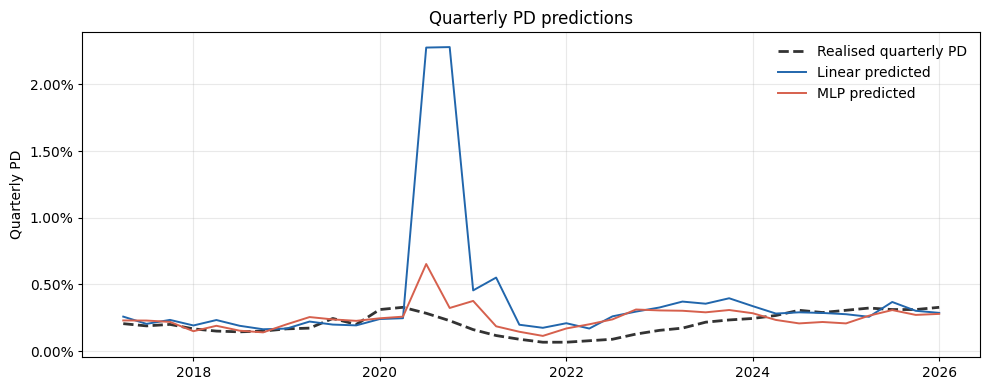

In [10]:
# 1. Quarterly PD predictions
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(plot_df["date"], plot_df["pd_q_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised quarterly PD")
ax.plot(plot_df["date"], plot_df["pd_q_hat_linear"], color=MODEL_COLORS["linear"], lw=1.4, label="Linear predicted")
ax.plot(plot_df["date"], plot_df["pd_q_hat_mlp"], color=MODEL_COLORS["mlp"], lw=1.4, label="MLP predicted")
ax.set_ylabel("Quarterly PD"); ax.set_title("Quarterly PD predictions"); ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
format_date_axis(ax); ax.legend(frameon=False); plt.tight_layout()
plt.savefig(FIGURES_DIR / "quarterly_pd_predictions.png", dpi=200, bbox_inches="tight"); plt.show()

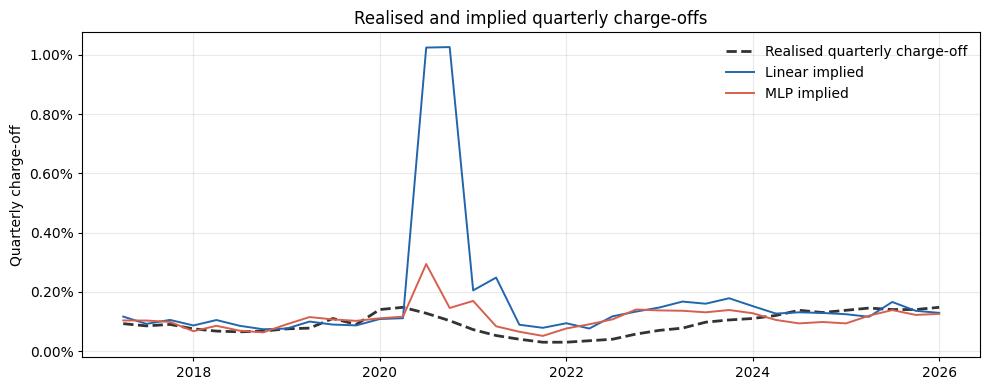

In [11]:
# 2. Quarterly charge-off predictions
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(plot_df["date"], plot_df["c_q_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised quarterly charge-off")
ax.plot(plot_df["date"], plot_df["c_q_hat_linear"], color=MODEL_COLORS["linear"], lw=1.4, label="Linear implied")
ax.plot(plot_df["date"], plot_df["c_q_hat_mlp"], color=MODEL_COLORS["mlp"], lw=1.4, label="MLP implied")
ax.set_ylabel("Quarterly charge-off"); ax.set_title("Realised and implied quarterly charge-offs"); ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
format_date_axis(ax); ax.legend(frameon=False); plt.tight_layout()
plt.savefig(FIGURES_DIR / "quarterly_chargeoff_predictions.png", dpi=200, bbox_inches="tight"); plt.show()

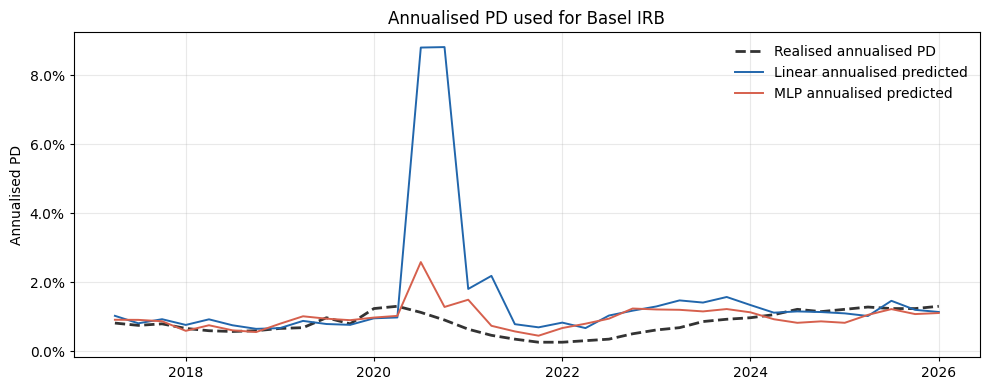

In [12]:
# 3. Annualised PD for IRB
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(plot_df["date"], plot_df["pd_a_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised annualised PD")
ax.plot(plot_df["date"], plot_df["pd_a_hat_linear"], color=MODEL_COLORS["linear"], lw=1.4, label="Linear annualised predicted")
ax.plot(plot_df["date"], plot_df["pd_a_hat_mlp"], color=MODEL_COLORS["mlp"], lw=1.4, label="MLP annualised predicted")
ax.set_ylabel("Annualised PD"); ax.set_title("Annualised PD used for Basel IRB"); ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
format_date_axis(ax); ax.legend(frameon=False); plt.tight_layout()
plt.savefig(FIGURES_DIR / "annualised_pd_irb.png", dpi=200, bbox_inches="tight"); plt.show()

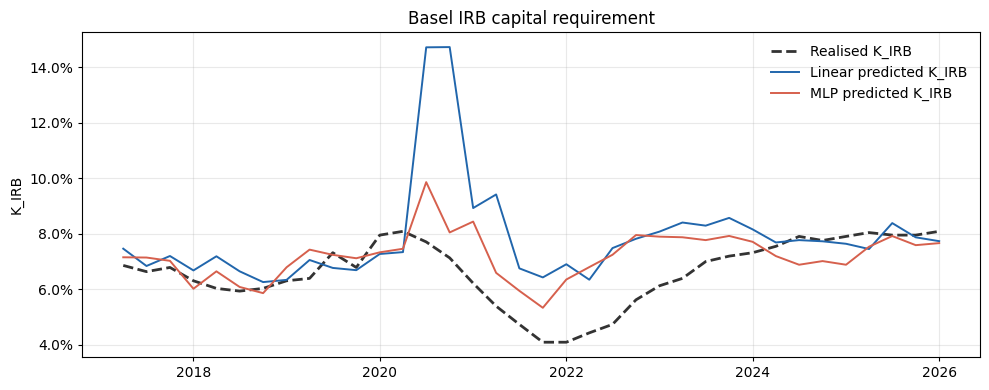

In [13]:
# 4. IRB capital requirement
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(plot_df["date"], plot_df["k_irb_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised K_IRB")
ax.plot(plot_df["date"], plot_df["k_irb_hat_linear"], color=MODEL_COLORS["linear"], lw=1.4, label="Linear predicted K_IRB")
ax.plot(plot_df["date"], plot_df["k_irb_hat_mlp"], color=MODEL_COLORS["mlp"], lw=1.4, label="MLP predicted K_IRB")
ax.set_ylabel("K_IRB"); ax.set_title("Basel IRB capital requirement"); ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
format_date_axis(ax); ax.legend(frameon=False); plt.tight_layout()
plt.savefig(FIGURES_DIR / "irb_capital_requirement.png", dpi=200, bbox_inches="tight"); plt.show()

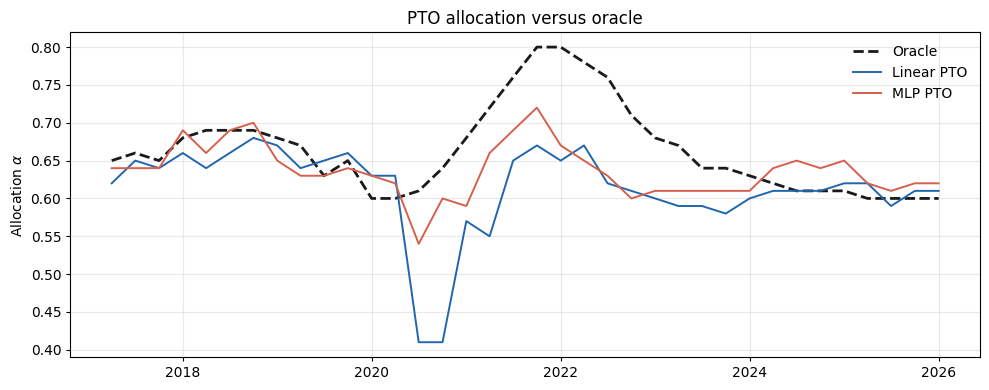

In [14]:
# 5. Allocation comparison
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Oracle")
ax.plot(plot_df["date"], plot_df["alpha_hat_linear"], color=MODEL_COLORS["linear"], lw=1.4, label="Linear PTO")
ax.plot(plot_df["date"], plot_df["alpha_hat_mlp"], color=MODEL_COLORS["mlp"], lw=1.4, label="MLP PTO")
ax.set_ylabel(r"Allocation $\alpha$"); ax.set_title("PTO allocation versus oracle")
format_date_axis(ax); ax.legend(frameon=False); plt.tight_layout()
plt.savefig(FIGURES_DIR / "allocation_comparison.png", dpi=200, bbox_inches="tight"); plt.show()

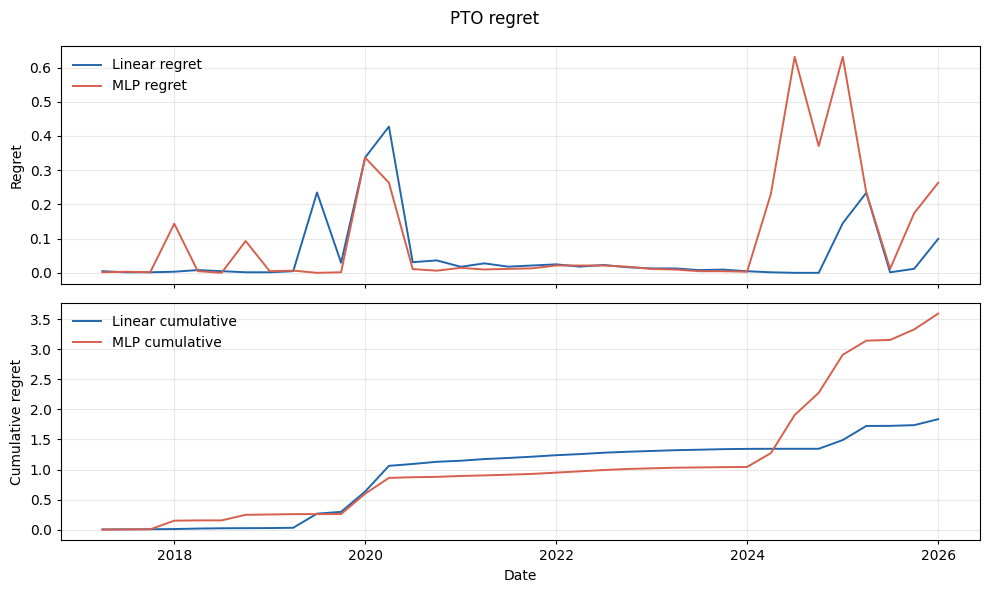

In [15]:
# 6. Regret and cumulative regret
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(plot_df["date"], plot_df["regret_linear"], color=MODEL_COLORS["linear"], lw=1.4, label="Linear regret")
axes[0].plot(plot_df["date"], plot_df["regret_mlp"], color=MODEL_COLORS["mlp"], lw=1.4, label="MLP regret")
axes[0].set_ylabel("Regret"); axes[0].legend(frameon=False)
axes[1].plot(plot_df["date"], plot_df["regret_linear"].cumsum(), color=MODEL_COLORS["linear"], lw=1.4, label="Linear cumulative")
axes[1].plot(plot_df["date"], plot_df["regret_mlp"].cumsum(), color=MODEL_COLORS["mlp"], lw=1.4, label="MLP cumulative")
axes[1].set_ylabel("Cumulative regret"); axes[1].set_xlabel("Date"); axes[1].legend(frameon=False)
for ax in axes: format_date_axis(ax)
fig.suptitle("PTO regret"); plt.tight_layout()
plt.savefig(FIGURES_DIR / "regret.png", dpi=200, bbox_inches="tight"); plt.show()

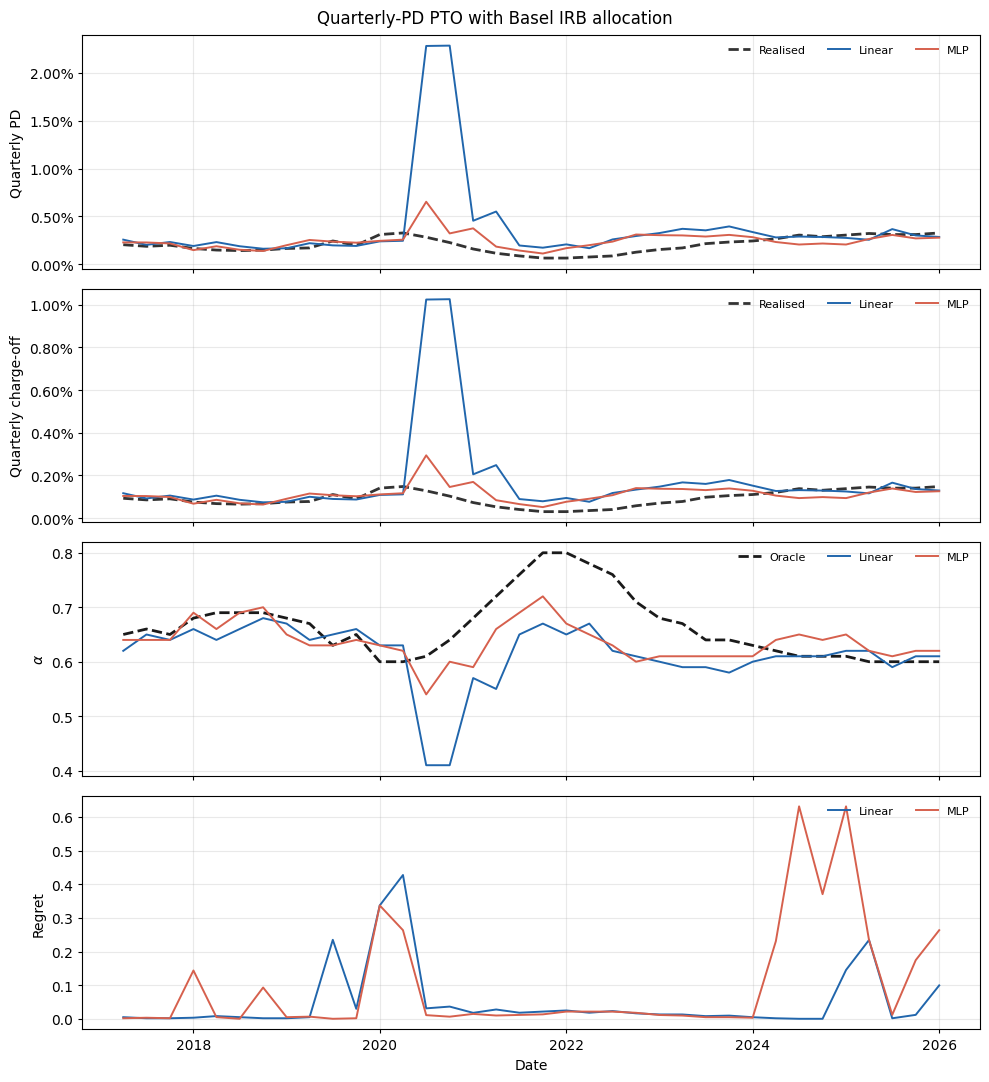

In [16]:
# 7. Compact 4-panel thesis figure
fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
fig.subplots_adjust(hspace=0.08)
axes[0].plot(plot_df["date"], plot_df["pd_q_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised")
axes[0].plot(plot_df["date"], plot_df["pd_q_hat_linear"], color=MODEL_COLORS["linear"], lw=1.4, label="Linear")
axes[0].plot(plot_df["date"], plot_df["pd_q_hat_mlp"], color=MODEL_COLORS["mlp"], lw=1.4, label="MLP")
axes[0].set_ylabel("Quarterly PD"); axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].plot(plot_df["date"], plot_df["c_q_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised")
axes[1].plot(plot_df["date"], plot_df["c_q_hat_linear"], color=MODEL_COLORS["linear"], lw=1.4, label="Linear")
axes[1].plot(plot_df["date"], plot_df["c_q_hat_mlp"], color=MODEL_COLORS["mlp"], lw=1.4, label="MLP")
axes[1].set_ylabel("Quarterly charge-off"); axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[2].plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Oracle")
axes[2].plot(plot_df["date"], plot_df["alpha_hat_linear"], color=MODEL_COLORS["linear"], lw=1.4, label="Linear")
axes[2].plot(plot_df["date"], plot_df["alpha_hat_mlp"], color=MODEL_COLORS["mlp"], lw=1.4, label="MLP")
axes[2].set_ylabel(r"$\alpha$")
axes[3].plot(plot_df["date"], plot_df["regret_linear"], color=MODEL_COLORS["linear"], lw=1.4, label="Linear")
axes[3].plot(plot_df["date"], plot_df["regret_mlp"], color=MODEL_COLORS["mlp"], lw=1.4, label="MLP")
axes[3].set_ylabel("Regret"); axes[3].set_xlabel("Date")
for ax in axes:
    format_date_axis(ax); ax.legend(fontsize=8, frameon=False, loc="upper right", ncol=3)
fig.suptitle("Quarterly-PD PTO with Basel IRB allocation", fontsize=12)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "pto_pd_irb_compact_panel.png", dpi=220, bbox_inches="tight"); plt.show()

## Learning curves

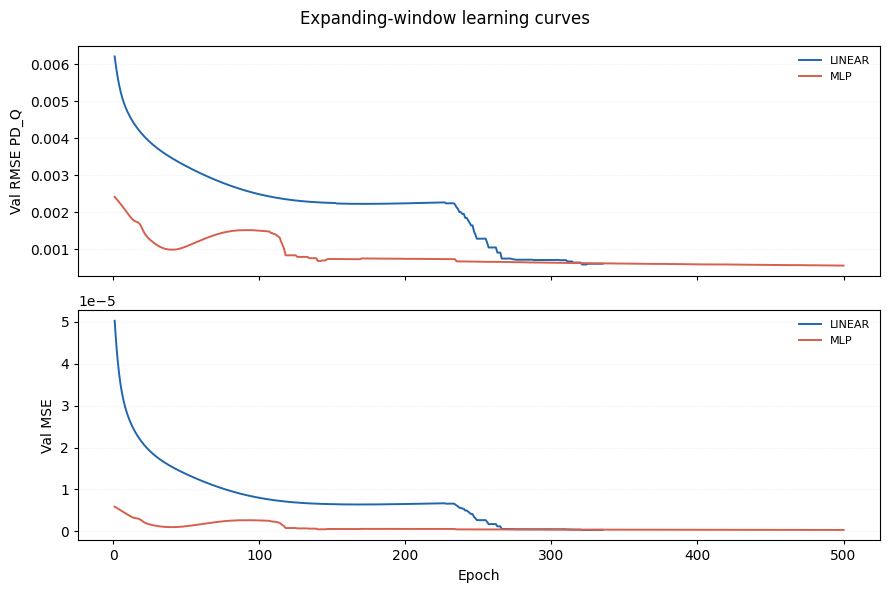

In [17]:
if not training_history.empty:
    mean_history = training_history.groupby(["model", "epoch"], as_index=False).agg(
        mean_val_rmse_pd_q=("val_rmse_pd_q", "mean"), mean_val_loss=("val_loss", "mean"))
    fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
    for model_name, group in mean_history.groupby("model"):
        group = group.sort_values("epoch"); color = MODEL_COLORS.get(model_name, "grey")
        axes[0].plot(group["epoch"], group["mean_val_rmse_pd_q"], color=color, lw=1.4, label=model_name.upper())
        axes[1].plot(group["epoch"], group["mean_val_loss"], color=color, lw=1.4, label=model_name.upper())
    axes[0].set_ylabel("Val RMSE PD_Q"); axes[1].set_ylabel("Val MSE"); axes[1].set_xlabel("Epoch")
    for ax in axes:
        ax.grid(True, axis="y", lw=0.5, alpha=0.3, linestyle=":"); ax.legend(fontsize=8, frameon=False, loc="upper right")
    fig.suptitle("Expanding-window learning curves"); plt.tight_layout()
    plt.savefig(FIGURES_DIR / "learning_curves.png", dpi=200, bbox_inches="tight"); plt.show()